In [1724]:
# # Pandas Data Cleaning Lab - Student Exercise

# ## Lab Overview

# In this hands-on lab, you will work with a messy customer sales dataset and apply various data cleaning techniques to prepare it for analysis. You will encounter real-world data quality issues and implement solutions to address them.

# **Learning Objectives:**
# - Identify and handle missing values using appropriate strategies
# - Detect and remove duplicate records
# - Standardize inconsistent data formats
# - Convert data types appropriately
# - Handle outliers effectively
# - Validate cleaned data

# **Prerequisites:**
# - Basic Python programming knowledge
# - Understanding of Pandas fundamentals
# - Familiarity with DataFrames and Series

# ## Dataset Description

# You will work with a customer sales dataset containing the following columns:

# | Column | Description | Expected Type |
# |--------|-------------|---------------|
# | customer_id | Unique customer identifier | Integer |
# | customer_name | Customer full name | String |
# | email | Customer email address | String |
# | phone | Customer phone number | String |
# | registration_date | Date customer registered | Datetime |
# | country | Customer country | String (Category) |
# | age | Customer age in years | Integer |
# | purchase_amount | Total purchase amount in dollars | Float |
# | product_category | Product category purchased | String (Category) |
# | payment_method | Payment method used | String (Category) |

# ## Part 1: Setup and Data Loading


In [1725]:
# ### Task 1.1: Import Required Libraries

# Import the necessary Python libraries for this lab.

# **Required Libraries:**
# - pandas
# - numpy
# - matplotlib.pyplot
# - seaborn (optional)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import dateutil
print("Pandas + NumPy handle cleaning, Matplotlib/Seaborn for visuals.")


Pandas + NumPy handle cleaning, Matplotlib/Seaborn for visuals.


In [1726]:
# ### Task 1.2: Load the Dataset
# Load the messy customer data from 'messy_customer_data.csv' into a DataFrame named `df`.
# **Hint:** Use `pd.read_csv()`
print("Dataset loaded ok")
print("First need to see data before doing anything")


print("loading thecsv into a dataframe  df")

df=pd.read_csv('/customersalesdatacsv.csv')
print(df)
print(df.head(10))

Dataset loaded ok
First need to see data before doing anything
loading thecsv into a dataframe  df
    customer_id      customer_name                   email             phone  \
0             1           John Doe      john.doe@email.com      123-456-7890   
1             2         jane smith    JANE.SMITH@email.com      (123)4567890   
2             3        Alice Brown         alice@email.com        1234567890   
3             4            Bob Lee           bob.lee@email               NaN   
4             5       Maria Garcia  maria.garcia@email.com   +34 600 123 456   
5             6             Li Wei                     NaN   +86 13800138000   
6             7          Omar Khan     omar.khan@email.com   +92-300-1234567   
7             8         Anne-Marie     annemarie@email.com  0044 7700 900123   
8             9       Chris O'Neil   chris.oneil@email.com      123.456.7890   
9            10     Sarah Connor    sarah.connor@email.com       1234567890    
10           11      

In [1727]:


### Task 1.3: Display Basic Information
'''
Display the following information about the dataset:
- Shape (rows and columns)
- First 10 rows
- Data types of all columns
- Basic statistical summary
'''
print("Expected Output:** You should see 10 rows and 10 columns in the dataset.")
print("Shape rows and coulms",'='*60)
print("rows and columns now:", df.shape)
print("keeping this to check after cleaning")
print("First 10 rows",'='*60)
print(df.head(10))
print("Data types of all columns",'='*60)
print(df.dtypes)
print("Basic statistical summary")
print("using only describe",'='*60)
print(df.describe())


Expected Output:** You should see 10 rows and 10 columns in the dataset.
Shape rows and coulms ============================================================
rows and columns now: (20, 10)
keeping this to check after cleaning
First 10 rows ============================================================
   customer_id      customer_name                   email             phone  \
0            1           John Doe      john.doe@email.com      123-456-7890   
1            2         jane smith    JANE.SMITH@email.com      (123)4567890   
2            3        Alice Brown         alice@email.com        1234567890   
3            4            Bob Lee           bob.lee@email               NaN   
4            5       Maria Garcia  maria.garcia@email.com   +34 600 123 456   
5            6             Li Wei                     NaN   +86 13800138000   
6            7          Omar Khan     omar.khan@email.com   +92-300-1234567   
7            8         Anne-Marie     annemarie@email.com  0044 7700 

include uses only numeric columns
include all uses all columns

In [1728]:
'''
## Part 2: Data Exploration and Quality Assessment
### Task 2.1: Identify Missing Values
Write code to:
1. Count missing values in each column
2. Calculate the percentage of missing values per column
3. Display the results
'''
print("Count missing values in each column",'='*60)
print(df.isna().sum())
print("Percentage of missing values",'='*60)
missing=df.isna().sum()
missing_pct=(missing/len(df))*100
print(missing_pct)
print('='*60)
print("display the results")
print(pd.DataFrame({'missing':missing,'missing_pct':missing_pct}))
print('='*60)

# **Questions to Answer:**
# Which column has the most missing values?
# - What percentage of the dataset is complete?
print("Which column the most missing values?")
print(missing.idxmax())
print("customer_name and phone column have more missing values")
print("what percentage of the data set is complete")
#print(100-missing_pct.mean())
complete_pct=100-(missing.sum()/(df.shape[0]*df.shape[1]))*100
# completeness doesnt look only null values point it looks at data set as a whole so rows *columns are considered
print(complete_pct)


Count missing values in each column ============================================================
customer_id          0
customer_name        1
email                1
phone                4
registration_date    1
country              0
age                  2
purchase_amount      1
product_category     1
payment_method       2
dtype: int64
Percentage of missing values ============================================================
customer_id           0.0
customer_name         5.0
email                 5.0
phone                20.0
registration_date     5.0
country               0.0
age                  10.0
purchase_amount       5.0
product_category      5.0
payment_method       10.0
dtype: float64
display the results
                   missing  missing_pct
customer_id              0          0.0
customer_name            1          5.0
email                    1          5.0
phone                    4         20.0
registration_date        1          5.0
country                  0         

In [1729]:
print(df)

    customer_id      customer_name                   email             phone  \
0             1           John Doe      john.doe@email.com      123-456-7890   
1             2         jane smith    JANE.SMITH@email.com      (123)4567890   
2             3        Alice Brown         alice@email.com        1234567890   
3             4            Bob Lee           bob.lee@email               NaN   
4             5       Maria Garcia  maria.garcia@email.com   +34 600 123 456   
5             6             Li Wei                     NaN   +86 13800138000   
6             7          Omar Khan     omar.khan@email.com   +92-300-1234567   
7             8         Anne-Marie     annemarie@email.com  0044 7700 900123   
8             9       Chris O'Neil   chris.oneil@email.com      123.456.7890   
9            10     Sarah Connor    sarah.connor@email.com       1234567890    
10           11       David Miller  david.miller@email.com      987-654-3210   
11           12        Priya Patel   pri

In [1730]:
### Task 2.2: Detect Duplicate Records
'''
Write code to:
1. Count the number of duplicate rows
2. Display all duplicate records (if any)
3. Identify which columns contain the duplicated information

**Questions to Answer:**
- How many duplicate records exist?
- What makes these records duplicates?

'''
print('='*60)
print("Count the number of duplicate rows")

print(df.duplicated().sum())
# column values are duplicated but not all columns in a row so0
print('='*60)

print(" Display all duplicate records (if any)")

print(df[df.duplicated()])
print('='*60)
print(" Identify which columns contain the duplicated information")
print('='*60)
df[df.duplicated(keep=False)]

print('='*60)
print("How many duplicate records exist?")
print("These many duplocate columns exits")
df[df.duplicated(keep=False)]

#printt(df.duplicated().sum())
print("number of duplicated record(rows)")
print(df.duplicated().sum())
print('='*60)
print("What makes these records duplicates?")
print("Records are duplicates only when all column values in a row are exactly the same")


Count the number of duplicate rows
0
 Display all duplicate records (if any)
Empty DataFrame
Columns: [customer_id, customer_name, email, phone, registration_date, country, age, purchase_amount, product_category, payment_method]
Index: []
 Identify which columns contain the duplicated information
How many duplicate records exist?
These many duplocate columns exits
number of duplicated record(rows)
0
What makes these records duplicates?
Records are duplicates only when all column values in a row are exactly the same


In [1731]:

### Task 2.3: Analyze Data Inconsistencies
'''
Examine the following columns for inconsistencies:
- `customer_name`: Check for formatting issues
- `country`: Check for case variations
- `product_category`: Check for case variations
- `payment_method`: Check for case variations
- `phone`: Check for different formats
- `email`: Check for formatting issues
'''
# **List all inconsistencies you find:**
# 1.
# 2.
# 3.
print('='*60)
print("customer_name: Check for formatting issues")
print(df['customer_name'].unique())
print('='*60)


print("country: Check for case variations")
print('='*60)

print("product_category: Check for case variations")
print(df['country'].unique())

print('='*60)

print("payment_method: Check for case variations")
print(df['payment_method'].unique())
print('='*60)

print("phone: Check for different formats")
print(df['phone'].unique())
print('='*60)

print("email: Check for formatting issues")
print(df['email'].unique())
print('='*60)

print("List all inconsistencies you find:")
print("country and product_category have upper and lower case mixed.")
print("phone numbers are stored in different formats.")
print("1. Formatting issues, case variations, multiple phone formats, and email issues")
print("date is inconsistent in date ::dd-mm-yyyy")
print("case  is inconsistent capital /small letter")
print("multiple phone formats, multiple formats because of country code")
print("email issues= invalid emails and nan values,missing domain extensions")
print('='*60)

customer_name: Check for formatting issues
['John Doe' 'jane smith' 'Alice Brown' 'Bob Lee' 'Maria Garcia' 'Li Wei'
 'Omar Khan' 'Anne-Marie' "Chris O'Neil" '   Sarah Connor  '
 'David Miller' 'Priya Patel' 'Ahmed Ali' 'Sofia Rossi' 'Lucas Martin'
 'Emily Clark' 'Daniel Kim' 'Fatima Noor' 'Carlos Diaz' nan]
country: Check for case variations
product_category: Check for case variations
['USA' 'usa' 'United States' 'Canada' 'Spain' 'China' 'Pakistan' 'UK'
 'U.S.A' 'India' 'UAE' 'Italy' 'France' 'South Korea' 'Mexico']
payment_method: Check for case variations
['Credit Card' 'credit card' 'PayPal' 'Debit' 'Cash' 'Bank Transfer'
 'Paypal' 'CREDIT CARD' nan 'Debit Card' 'UPI']
phone: Check for different formats
['123-456-7890' '(123)4567890' '1234567890' nan '+34 600 123 456'
 '+86 13800138000' '+92-300-1234567' '0044 7700 900123' '123.456.7890'
 ' 1234567890 ' '987-654-3210' '91-9876543210' '+39 333 1234567'
 '+33 612345678' '+82 10-1234-5678' '+971 50 123 4567' '52-5512345678']
email: Che

In [1732]:
'''### Task 2.4: Identify Invalid Values
Check for invalid values in:
1. `age`: Negative values or unrealistic ages (>120)
2. `purchase_amount`: Negative values or extreme outliers
3. `email`: Invalid email formats
**Document your findings:**
- Invalid age values found:
- Invalid purchase amounts found:
- Invalid email formats found:
---
'''
print("Check for invalid values in:")
print('='*60)
print("age: Negative values or unrealistic ages (>120)")
print(df[df['age']<=0])
print('='*60)
print("purchase_amount: Negative values or extreme outliers")
print("negative values")
print(df[df['purchase_amount']<0])
print("outliers")
Q1=df['purchase_amount'].quantile(0.25)
Q3=df['purchase_amount'].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
print(df[(df['purchase_amount']<lower)|(df['purchase_amount']>upper)])
print('='*60)
print("emafdfil: Invalid email formats")
df[~df['email'].str.contains('@', na=False)]
print('='*60)
print("Document your findings:")
print("some age negative found")
print("purchase amount negative and outliers found not in range of regular purchases which is 9999")
print("email invalid format found")

Check for invalid values in:
age: Negative values or unrealistic ages (>120)
   customer_id customer_name          email phone registration_date country  \
3            4       Bob Lee  bob.lee@email   NaN        2022-12-30  Canada   

   age  purchase_amount product_category payment_method  
3 -5.0              0.0             Home          Debit  
purchase_amount: Negative values or extreme outliers
negative values
    customer_id customer_name                   email            phone  \
4             5  Maria Garcia  maria.garcia@email.com  +34 600 123 456   
18           19   Carlos Diaz   carlos.diaz@email.com    52-5512345678   

   registration_date country   age  purchase_amount product_category  \
4         2023/04/10   Spain  39.0            -50.0           Beauty   
18        2023-11-20  Mexico  44.0            -20.0           Sports   

   payment_method  
4            Cash  
18            NaN  
outliers
   customer_id customer_name                  email         phone  \
8

In [1733]:
## Part 3: Handling Missing Values
'''
### Task 3.1: Create a Cleaning Strategy

Before handling missing values, create a strategy for each column. Fill in the table:

| Column | Strategy | Justification |
|--------|----------|---------------|
| customer_id | | |
| customer_name | | |
| email | | |
| phone | | |
| registration_date | | |
| age | | |
| purchase_amount | | |
| product_category | | |
| payment_method | | |

**Common Strategies:**
- Drop rows with missing values
- Fill with mean/median/mode
- Fill with a constant value
- Forward fill / Backward fill
- Fill with interpolation
'''
print("Before handling missing values, create a strategy for each column. Fill in the table:")
print('='*60)
print("| Column | Strategy | Justification |")
print("|--------|----------|---------------|")

print("| customer_id | Do not fill | Unique identifier, no missing values |")
print("| customer_name | Fill with mode | Most common name used to preserve records |")
print("| email | Fill with constant ('unknown@email.com') | Missing and invalid emails present |")
print("| phone | Fill with constant ('000-0000') | Multiple formats and missing values |")
print("| registration_date | Fill with mode | Dates exist in multiple formats with some missing |")
print("| age | Fill with median | Numeric data with missing values and outliers |")
print("| purchase_amount | Fill with median | Prevent effect of extreme outliers |")
print("| product_category | Fill with mode | Categorical column with missing values |")
print("| payment_method | Fill with mode | Categorical column with missing values |")

print('='*60)

Before handling missing values, create a strategy for each column. Fill in the table:
| Column | Strategy | Justification |
|--------|----------|---------------|
| customer_id | Do not fill | Unique identifier, no missing values |
| customer_name | Fill with mode | Most common name used to preserve records |
| email | Fill with constant ('unknown@email.com') | Missing and invalid emails present |
| phone | Fill with constant ('000-0000') | Multiple formats and missing values |
| registration_date | Fill with mode | Dates exist in multiple formats with some missing |
| age | Fill with median | Numeric data with missing values and outliers |
| purchase_amount | Fill with median | Prevent effect of extreme outliers |
| product_category | Fill with mode | Categorical column with missing values |
| payment_method | Fill with mode | Categorical column with missing values |


In [1734]:

print("loaded th ecsv into a dataframe  df")
# df


### Task 3.2: Implement Missing Value Handling

# Create a copy of the original DataFrame called `df_clean` and implement your strategy:

# ```python
# # Create a copy
print("df is my saved original data frame")
print("df_cleaned is my working data frame")
df_clean = df.copy()
#df_original=df.copy()

# this should be done at last as we should fill them with common methods
#print("- Drop rows with missing values")
#df_clean=df_clean.dropna()
# Implement your strategy for each column


print("Common Strategies:")

print("fill with meand and median")
df_clean['purchase_amount']=df_clean['purchase_amount'].fillna(df_clean['purchase_amount'].median())
df_clean['product_category']=df_clean['product_category'].fillna(df_clean['product_category'].mode()[0])
df_clean['age']=df_clean['age'].fillna(df_clean['age'].median())


print(df_clean['email'].isna().sum())
print(df_clean['email'].unique())
print("filling email with some default as its personal")
 #df_clean['email']=df_clean['email'].fillna('unknown@email.com')
df_clean['email'] = df_clean['email'].fillna('unknown@example.com')
df_clean.loc[~df_clean['email'].str.contains('@',na=False),'email']='unknown@example.com'

print("filing phone with default")
df_clean['phone'] = df_clean['phone'].astype(str).fillna('000-0000')

print("fill with forward mode")
median1=df_clean['purchase_amount'].median()
age_median=df_clean['age'].median()
df_clean['purchase_amount'] = df_clean['purchase_amount'].abs()

df_clean.loc[df_clean['age']<0,'age']=age_median

# df_clean['registration_date']=df_clean['registration_date'].ffill()
# df_clean['registration_date'] = pd.to_datetime(    df_clean['registration_date'],format='%Y-%m-%d',    errors='coerce')

# median_date = df_clean['registration_date'].median()
# # df_clean['registration_date'] = df_clean['registration_date'].fillna(median_date)
# df_clean['registration_date']=df_clean['registration_date'].fillna(median_date)

# print("this ensures all  are filled with some value")
# df_clean=df_clean.ffill()
# should be mostly avoided to avoid random fill
# df_clean=df_clean.bfill()
print("interpolate means estimating from nearby values")
df_clean['purchase_amount']=df_clean['purchase_amount'].interpolate()

df_clean.loc[df_clean['email']=='invalid_email','email']='unknown@email.com'
print("- Drop rows with missing values")
df_clean=df_clean.dropna()
print('='*60)
print(df_clean)

loaded th ecsv into a dataframe  df
df is my saved original data frame
df_cleaned is my working data frame
Common Strategies:
fill with meand and median
1
['john.doe@email.com' 'JANE.SMITH@email.com' 'alice@email.com'
 'bob.lee@email' 'maria.garcia@email.com' nan 'omar.khan@email.com'
 'annemarie@email.com' 'chris.oneil@email.com' 'sarah.connor@email.com'
 'david.miller@email.com' 'priya.patel@email.com' 'ahmed.ali@email.com'
 'sofia.rossi@email.com' 'lucas.martin@email.com' 'emily.clark@email.com'
 'daniel.kim@email.com' 'fatima.noor@email.com' 'carlos.diaz@email.com'
 'invalid_email']
filling email with some default as its personal
filing phone with default
fill with forward mode
interpolate means estimating from nearby values
- Drop rows with missing values
    customer_id customer_name                   email             phone  \
0             1      John Doe      john.doe@email.com      123-456-7890   
1             2    jane smith    JANE.SMITH@email.com      (123)4567890   
2   

In [1735]:
# ### Task 3.3: Verify Missing Value Handling

# Write code to verify that all missing values have been handled appropriately:
print("0 is None values")
print(df_clean.isna().sum())
# **Expected Result:** Zero missing values in all columns (or only in columns you intentionally left with missing values).

0 is None values
customer_id          0
customer_name        0
email                0
phone                0
registration_date    0
country              0
age                  0
purchase_amount      0
product_category     0
payment_method       0
dtype: int64


In [1736]:
# ## Part 4: Removing Duplicates
# ### Task 4.1: Remove Duplicate Records

# Remove duplicate records from `df_clean`, keeping the first occurrence.

# **Hint:** Consider which columns should be used to identify duplicates.
# '''
print(" may be use email and phone as they  are  unique")
df_clean=df_clean.drop_duplicates(subset=['email','phone'],keep='first')

 may be use email and phone as they  are  unique


In [1737]:
print("present")
print(df_clean)

present
    customer_id customer_name                   email             phone  \
0             1      John Doe      john.doe@email.com      123-456-7890   
1             2    jane smith    JANE.SMITH@email.com      (123)4567890   
2             3   Alice Brown         alice@email.com        1234567890   
3             4       Bob Lee           bob.lee@email               nan   
4             5  Maria Garcia  maria.garcia@email.com   +34 600 123 456   
5             6        Li Wei     unknown@example.com   +86 13800138000   
6             7     Omar Khan     omar.khan@email.com   +92-300-1234567   
7             8    Anne-Marie     annemarie@email.com  0044 7700 900123   
8             9  Chris O'Neil   chris.oneil@email.com      123.456.7890   
10           11  David Miller  david.miller@email.com      987-654-3210   
11           12   Priya Patel   priya.patel@email.com     91-9876543210   
12           13     Ahmed Ali     ahmed.ali@email.com               nan   
13           14  

In [1738]:
print("original")
print(df)

original
    customer_id      customer_name                   email             phone  \
0             1           John Doe      john.doe@email.com      123-456-7890   
1             2         jane smith    JANE.SMITH@email.com      (123)4567890   
2             3        Alice Brown         alice@email.com        1234567890   
3             4            Bob Lee           bob.lee@email               NaN   
4             5       Maria Garcia  maria.garcia@email.com   +34 600 123 456   
5             6             Li Wei                     NaN   +86 13800138000   
6             7          Omar Khan     omar.khan@email.com   +92-300-1234567   
7             8         Anne-Marie     annemarie@email.com  0044 7700 900123   
8             9       Chris O'Neil   chris.oneil@email.com      123.456.7890   
9            10     Sarah Connor    sarah.connor@email.com       1234567890    
10           11       David Miller  david.miller@email.com      987-654-3210   
11           12        Priya Pa

In [1739]:
### Task 4.2: Verify Duplicate Removal

print("Verify that no duplicates remain:")
print(df_clean.duplicated(subset=['email','phone']).sum())

'''
**Questions:**
'''
print("how many rows drop")
#-How many rows were removed?

#print("no rows where dropped to not to loose data missing values are filled ")
print(len(df)-len(df_clean))
'''
- What is the new shape of the dataset?
'''
print("Original rows:",df.shape[0])
print("Current rows:",df_clean.shape[0])

Verify that no duplicates remain:
0
how many rows drop
3
Original rows: 20
Current rows: 17


In [1740]:
# ## Part 5: Data Standardization

# ### Task 5.1: Standardize Customer Names

# Standardize the `customer_name` column to Title Case with no extra whitespace.

# **Example:** "  john doe  " → "John Doe"
# remove extra spaces + convert to capital Case
df_clean['customer_name']=df_clean['customer_name'].str.strip().str.title()
print(df_clean['customer_name'])

0         John Doe
1       Jane Smith
2      Alice Brown
3          Bob Lee
4     Maria Garcia
5           Li Wei
6        Omar Khan
7       Anne-Marie
8     Chris O'Neil
10    David Miller
11     Priya Patel
12       Ahmed Ali
13     Sofia Rossi
14    Lucas Martin
15     Emily Clark
16      Daniel Kim
17     Fatima Noor
Name: customer_name, dtype: object


In [1741]:
### Task 5.2: Standardize Email Addresses

print("Standardize the `email` column to lowercase with no extra whitespace.")
df_clean['email']=df_clean['email'].str.strip().str.lower()
print(df_clean['email'])

Standardize the `email` column to lowercase with no extra whitespace.
0         john.doe@email.com
1       jane.smith@email.com
2            alice@email.com
3              bob.lee@email
4     maria.garcia@email.com
5        unknown@example.com
6        omar.khan@email.com
7        annemarie@email.com
8      chris.oneil@email.com
10    david.miller@email.com
11     priya.patel@email.com
12       ahmed.ali@email.com
13     sofia.rossi@email.com
14    lucas.martin@email.com
15     emily.clark@email.com
16      daniel.kim@email.com
17     fatima.noor@email.com
Name: email, dtype: object


In [1742]:
### Task 5.3: Standardize Phone Numbers
print("Standardize the `phone` column to a consistent format: XXX-XXXX")
#**Example:** "(555) 1234", "555.1234", "5551234" → "555-1234"

df_clean['phone']=df_clean['phone'].fillna('0000000')
df_clean['phone']=df_clean['phone'].astype(str)

df_clean['phone']=df_clean['phone'].str.replace(r'[^0-9]','',regex=True)

# # take last 7 digits
df_clean['phone']=df_clean['phone'].str[-7:]
#df_clean['phone'] = df_clean['phone'].str.replace(r'\D', '', regex=True).str.zfill(7).str[-7:]

# format  as XXX-XXXX
df_clean['phone']=df_clean['phone'].str[:3]+'-'+df_clean['phone'].str[3:]
print(df_clean['phone'])
#**Hint:** Remove all non-numeric characters first, then format.

Standardize the `phone` column to a consistent format: XXX-XXXX
0     456-7890
1     456-7890
2     456-7890
3            -
4     012-3456
5     013-8000
6     123-4567
7     090-0123
8     456-7890
10    654-3210
11    654-3210
12           -
13    123-4567
14    234-5678
15           -
16    234-5678
17    123-4567
Name: phone, dtype: object


In [1743]:
### Task 5.4: Standardize Country Names

print("Standardize the `country` column to uppercase.")
df_clean['country']=df_clean['country'].str.upper()
print(df_clean['country'])



Standardize the `country` column to uppercase.
0               USA
1               USA
2     UNITED STATES
3            CANADA
4             SPAIN
5             CHINA
6          PAKISTAN
7                UK
8               USA
10              USA
11            INDIA
12              UAE
13            ITALY
14           FRANCE
15              USA
16      SOUTH KOREA
17              UAE
Name: country, dtype: object


In [1744]:
### Task 5.5: Standardize Product Categories
print("Standardize the `product_category` column to Title Case.")
df_clean['product_category']=df_clean['product_category'].str.title()
print(df_clean['product_category'])

Standardize the `product_category` column to Title Case.
0     Electronics
1     Electronics
2        Clothing
3            Home
4          Beauty
5     Electronics
6          Sports
7        Clothing
8     Electronics
10           Home
11         Beauty
12    Electronics
13       Clothing
14         Sports
15           Home
16    Electronics
17         Beauty
Name: product_category, dtype: object


In [1745]:
### Task 5.6: Standardize Payment Methods

print("Standardize the `payment_method` column to Title Case.")
df_clean['payment_method'] = df_clean['payment_method'].str.title()
print(df_clean['payment_method'])


Standardize the `payment_method` column to Title Case.
0       Credit Card
1       Credit Card
2            Paypal
3             Debit
4              Cash
5       Credit Card
6     Bank Transfer
7            Paypal
8       Credit Card
10       Debit Card
11              Upi
12             Cash
13      Credit Card
14            Debit
15      Credit Card
16    Bank Transfer
17             Cash
Name: payment_method, dtype: object


In [1746]:
df_clean['payment_method']=df_clean['payment_method'].replace({
    'Debit':'Debit Card',
    'Upi':'UPI',
    'Paypal':'PayPal'
})
print(df_clean['payment_method'])


0       Credit Card
1       Credit Card
2            PayPal
3        Debit Card
4              Cash
5       Credit Card
6     Bank Transfer
7            PayPal
8       Credit Card
10       Debit Card
11              UPI
12             Cash
13      Credit Card
14       Debit Card
15      Credit Card
16    Bank Transfer
17             Cash
Name: payment_method, dtype: object


In [1747]:
### Task 5.7: Verify Standardization

print("Display unique values for all categorical columns to verify standardization")
print("country")
print(df_clean['country'].unique())
print("product category")
print(df_clean['product_category'].unique())
print("payment method")
print(df_clean['payment_method'].unique())


Display unique values for all categorical columns to verify standardization
country
['USA' 'UNITED STATES' 'CANADA' 'SPAIN' 'CHINA' 'PAKISTAN' 'UK' 'INDIA'
 'UAE' 'ITALY' 'FRANCE' 'SOUTH KOREA']
product category
['Electronics' 'Clothing' 'Home' 'Beauty' 'Sports']
payment method
['Credit Card' 'PayPal' 'Debit Card' 'Cash' 'Bank Transfer' 'UPI']


In [1748]:

## Part 6: Data Type Conversion
### Task 6.1: Convert customer_id to Integer

print("Convert the `customer_id` column to integer type.")
print(df_clean['customer_id'].dtype)
df_clean['customer_id'] = df_clean['customer_id'].astype(int)
print(df_clean['customer_id'].dtype)
print(df_clean['customer_id'])


Convert the `customer_id` column to integer type.
int64
int64
0      1
1      2
2      3
3      4
4      5
5      6
6      7
7      8
8      9
10    11
11    12
12    13
13    14
14    15
15    16
16    17
17    18
Name: customer_id, dtype: int64


In [1749]:
# ### Task 6.2: Convert registration_date to Datetime

# Convert the `registration_date` column to datetime type. Handle multiple date formats.

# **Formats present:** 'YYYY-MM-DD', 'DD/MM/YYYY', 'MM-DD-YYYY', 'YYYY/MM/DD'


print(df_clean['registration_date'])
print(df_clean['registration_date'].dtype)
from dateutil import parser

s = df_clean['registration_date'].astype(str)

df_clean['registration_date'] = s.apply(
    lambda x: parser.parse(x, dayfirst=True, fuzzy=True)
    if x not in ['NaT', 'None', 'nan'] else pd.NaT
)

print("only with dateutil has correctly coverted date avoiding random date filling ")
# s = df_clean['registration_date'].astype(str)

# s = (
#     s.str.replace(r'(\d{4})\.(\d{2})\.(\d{2})', r'\1-\2-\3', regex=True)
#      .str.replace('/', '-', regex=False)
# )

# parsed = pd.to_datetime(s, errors='coerce', dayfirst=False)
# mask = parsed.isna()
# parsed[mask] = pd.to_datetime(s[mask], errors='coerce', dayfirst=True)

# df_clean['registration_date'] = parsed
# df_clean['registration_date'] = df_clean['registration_date'].astype(str)
# print(" Convert the `registration_date` column to datetime type. Handle multiple date formats.")
# df_clean['registration_date'] = pd.to_datetime(
#     df_clean['registration_date'],
#     errors='coerce'
# )


# def parse_date(x):
#     for fmt in ("%Y-%m-%d","%Y/%m/%d","%Y.%m.%d","%d-%m-%Y","%B %d, %Y"):
#         try:
#             return pd.to_datetime(x,format=fmt)
#         except:
#             pass
#     return pd.NaT

# df_clean['registration_date']=df_clean['registration_date'].apply(parse_date)
# df_clean['registration_date']=pd.to_datetime(
#     df_clean['registration_date'],
#     errors='coerce',
#     dayfirst=True,
#     infer_datetime_format=True
# )

# df_clean['registration_date']=df_clean['registration_date']=pd.to_datetime(df_clean['registration_date'],errors='coerce',  dayfirst=True)

# df_clean['registration_date'] = pd.to_datetime(
#     df_clean['registration_date'],
#     errors='coerce'
# )


print(df_clean['registration_date'])
print(df_clean['registration_date'].dtype)


# print(df_clean['registration_date'])

# df_clean['registration_date']=pd.to_datetime(
#     df_clean['registration_date'],
#     errors='coerce',
#     dayfirst=True,
#     infer_datetime_format=True
# )
# df_clean['registration_date']=df_clean['registration_date']=pd.to_datetime(df_clean['registration_date'],errors='coerce',  dayfirst=True)


# # df_clean['registration_date']=df_clean['registration_date'].ffill()
# # df_clean['registration_date']=df_clean['registration_date'].bfill()


0            2023-01-15
1            15/02/2023
2            2023.03.01
3            2022-12-30
4            2023/04/10
5            2023-05-20
6          May 25, 2023
7            2023-06-01
8            2023-06-15
10           2023-07-01
11           01-08-2023
12           2023/08/15
13    September 1, 2023
14           2023-09-10
15           2023.10.01
16           2023-10-15
17           15/11/2023
Name: registration_date, dtype: object
object
only with dateutil has correctly coverted date avoiding random date filling 
0    2023-01-15
1    2023-02-15
2    2023-01-03
3    2022-12-30
4    2023-10-04
5    2023-05-20
6    2023-05-25
7    2023-01-06
8    2023-06-15
10   2023-01-07
11   2023-08-01
12   2023-08-15
13   2023-09-01
14   2023-10-09
15   2023-01-10
16   2023-10-15
17   2023-11-15
Name: registration_date, dtype: datetime64[ns]
datetime64[ns]


In [1750]:
### Task 6.3: Convert Categorical Columns

#
print("Convert `country`, `product_category`, and `payment_method` to categorical type for memory efficiency.")
df_clean['country']=df_clean['country'].astype('category')
df_clean['product_category']=df_clean['product_category'].astype('category')

df_clean['payment_method']=df_clean['payment_method'].str.strip().str.title()
df_clean['payment_method']=df_clean['payment_method'].astype('category')
print(df_clean['payment_method'])
print(df_clean['payment_method'].dtype)


print(df_clean.dtypes)

Convert `country`, `product_category`, and `payment_method` to categorical type for memory efficiency.
0       Credit Card
1       Credit Card
2            Paypal
3        Debit Card
4              Cash
5       Credit Card
6     Bank Transfer
7            Paypal
8       Credit Card
10       Debit Card
11              Upi
12             Cash
13      Credit Card
14       Debit Card
15      Credit Card
16    Bank Transfer
17             Cash
Name: payment_method, dtype: category
Categories (6, object): ['Bank Transfer', 'Cash', 'Credit Card', 'Debit Card', 'Paypal', 'Upi']
category
customer_id                   int64
customer_name                object
email                        object
phone                        object
registration_date    datetime64[ns]
country                    category
age                         float64
purchase_amount             float64
product_category           category
payment_method             category
dtype: object


In [1751]:
### Task 6.4: Ensure Proper Numeric Types

print("Ensure `age` is integer and `purchase_amount` is float.")
df_clean['age']=df_clean['age'].astype(int)
df_clean['purchase_amount']=df_clean['purchase_amount'].astype(float)
print(df_clean.dtypes)


Ensure `age` is integer and `purchase_amount` is float.
customer_id                   int64
customer_name                object
email                        object
phone                        object
registration_date    datetime64[ns]
country                    category
age                           int64
purchase_amount             float64
product_category           category
payment_method             category
dtype: object


In [1752]:
### Task 6.5: Verify Data Types
print("Display the data types of all columns to verify conversions:")
print(df_clean.dtypes)


Display the data types of all columns to verify conversions:
customer_id                   int64
customer_name                object
email                        object
phone                        object
registration_date    datetime64[ns]
country                    category
age                           int64
purchase_amount             float64
product_category           category
payment_method             category
dtype: object


In [1753]:
## Part 7: Handling Outliers and Invalid Values
### Task 7.1: Fix Invalid Ages
# Identify and fix:
# - Negative ages
# - Ages greater than 120
# **Strategy:** Replace invalid ages with the median age.

#df1=pd.read_csv('/customersalesdatacsv.csv')


print(df_clean['age'])
print("Invalid columns")
df_clean.loc[df_clean['age']<0,'age']=df_clean['age'].median()
print(df_clean[(df_clean['age']<0)|(df_clean['age']>120)]['age'])
#print(df1['age'].isna()=="True")
print("Nan age columns",'='*60)
print(df_clean[df_clean['age'].isna()]['age'])
print("no nan age columns as already missing values are filled")
median_age=df_clean['age'].median()
print("Median age used:",median_age)
#df1.loc[(df1['age']<0)|(df1['age']>120),'age']=median_age
median_age=df_clean['age'].median()
df_clean.loc[(df_clean['age']<0)|(df_clean['age']>120),'age']=median_age
df_clean.loc[df_clean['age'].isna(),'age']=median_age

print(df_clean['age'])


0      28
1      34
2      45
3      33
4      39
5      30
6      33
7      25
8      40
10    120
11     29
12     33
13     41
14     27
15     35
16     31
17     33
Name: age, dtype: int64
Invalid columns
Series([], Name: age, dtype: int64)
Nan age columns ============================================================
Series([], Name: age, dtype: int64)
no nan age columns as already missing values are filled
Median age used: 33.0
0      28
1      34
2      45
3      33
4      39
5      30
6      33
7      25
8      40
10    120
11     29
12     33
13     41
14     27
15     35
16     31
17     33
Name: age, dtype: int64


In [1754]:
### Task 7.2: Handle Purchase Amount Outliers
'''
Use the IQR (Interquartile Range) method to:
1. Calculate Q1, Q3, and IQR
2. Determine lower and upper bounds
3. Identify outliers
4. Handle outliers by capping them at the bounds

**Formula:**
- IQR = Q3 - Q1
- Lower Bound = Q1 - 1.5 × IQR
- Upper Bound = Q3 + 1.5 × IQR
'''
q1=df_clean['purchase_amount'].quantile(0.25)
q2=df_clean['purchase_amount'].quantile(0.75)
print("q1",q1)
print("q2",q2)

iqr=q2-q1
print("interquartile range",iqr)
lower=q1-1.5*iqr
upper=q2+1.5*iqr
print("lower",lower)
print("upper",upper)
print("outliers")
print(df_clean[(df_clean['purchase_amount']<lower)|(df_clean['purchase_amount']>upper)]['purchase_amount'])

'''
**Questions:**
- How many outliers were identified?
- What were the outlier values?
- What is the new range of purchase amounts?
'''
print("How many outliers were identified?")
print("outliers count")
print(len(df_clean[(df_clean['purchase_amount']<lower)|(df_clean['purchase_amount']>upper)]))
print("What were the outlier values?")
print("outliers values")
print(df_clean[(df_clean['purchase_amount']<lower)|(df_clean['purchase_amount']>upper)]['purchase_amount'])
df_clean.loc[df_clean['purchase_amount']<lower,'purchase_amount']=lower
df_clean.loc[df_clean['purchase_amount']>upper,'purchase_amount']=upper

print("What is the new range of purchase amounts?")
print("new range of purchase amounts")
print(df_clean['purchase_amount'].min())
print(df_clean['purchase_amount'].max())
print("all purchase_amounts")

print(df_clean['purchase_amount'])



q1 120.5
q2 410.0
interquartile range 289.5
lower -313.75
upper 844.25
outliers
8    9999.0
Name: purchase_amount, dtype: float64
How many outliers were identified?
outliers count
1
What were the outlier values?
outliers values
8    9999.0
Name: purchase_amount, dtype: float64
What is the new range of purchase amounts?
new range of purchase amounts
0.0
844.25
all purchase_amounts
0     250.75
1     340.00
2     120.50
3       0.00
4      50.00
5     560.99
6     300.00
7      75.25
8     844.25
10    450.00
11    220.75
12    180.00
13    310.40
14     95.99
15    410.00
16    275.60
17    600.00
Name: purchase_amount, dtype: float64


In [1755]:
print(df_clean)

    customer_id customer_name                   email     phone  \
0             1      John Doe      john.doe@email.com  456-7890   
1             2    Jane Smith    jane.smith@email.com  456-7890   
2             3   Alice Brown         alice@email.com  456-7890   
3             4       Bob Lee           bob.lee@email         -   
4             5  Maria Garcia  maria.garcia@email.com  012-3456   
5             6        Li Wei     unknown@example.com  013-8000   
6             7     Omar Khan     omar.khan@email.com  123-4567   
7             8    Anne-Marie     annemarie@email.com  090-0123   
8             9  Chris O'Neil   chris.oneil@email.com  456-7890   
10           11  David Miller  david.miller@email.com  654-3210   
11           12   Priya Patel   priya.patel@email.com  654-3210   
12           13     Ahmed Ali     ahmed.ali@email.com         -   
13           14   Sofia Rossi   sofia.rossi@email.com  123-4567   
14           15  Lucas Martin  lucas.martin@email.com  234-567

In [1756]:
## Part 8: Data Validation

### Task 8.1: Validate Completeness

print("Write assertions to verify that the cleaned data has no missing values:")
print(df_clean.isna().sum().sum())
print("Validation passed: No missing values in cleaned data")

Write assertions to verify that the cleaned data has no missing values:
0
Validation passed: No missing values in cleaned data


In [1757]:
### Task 8.2: Validate Uniqueness

print("Write assertions to verify that no duplicate records exis")
print(df_clean.duplicated().sum())
print("Validated: No duplicate records in  data")
assert df_clean.duplicated().sum()==0,"Duplicate records found in  data"


Write assertions to verify that no duplicate records exis
0
Validated: No duplicate records in  data


In [1758]:

### Task 8.3: Validate Data Types

print("Write assertions to verify that all columns have the correct data type:")
print(df_clean.dtypes)
assert df_clean['customer_id'].dtype=='int64'
assert df_clean['registration_date'].dtype=='datetime64[ns]'
assert df_clean['age'].dtype=='int64'
assert df_clean['purchase_amount'].dtype=='float64'
assert df_clean['country'].dtype.name=='category'
assert df_clean['product_category'].dtype.name=='category'
assert df_clean['payment_method'].dtype.name=='category'
assert df_clean['country'].dtype.name=='category'
assert df_clean['product_category'].dtype.name=='category'
assert df_clean['payment_method'].dtype.name=='category'
assert df_clean['customer_name'].dtype.name=='object'
assert df_clean['email'].dtype.name=='object'

print("Validated: All columns have correct data types")



Write assertions to verify that all columns have the correct data type:
customer_id                   int64
customer_name                object
email                        object
phone                        object
registration_date    datetime64[ns]
country                    category
age                           int64
purchase_amount             float64
product_category           category
payment_method             category
dtype: object
Validated: All columns have correct data types


In [1759]:
### Task 8.4: Validate Value Ranges

# Write assertions to verify:
# - Age is between 1 and 120
# assert (df_clean['age']>=1).all() and (df_clean['age']<=120).all(),"age is not between 1 and 120"
# assert (df_clean['age'] >= 1).all() and (df_clean['age'] <= 120).all(), "age is not between 1 and 120"
assert df_clean['age'].between(1,120).all(), "Age out of valid range"

# - Purchase amount is positive
assert (df_clean['purchase_amount'] >= 0).all(), "purchase amount is not positive"
# - All required categorical values are standardized
# print("country")
# print(df_clean['country'])
country_map = {
    'UNITED STATES': 'USA',  'U.S.A': 'USA',  'US': 'USA',
    'AMERICA': 'USA', 'UK': 'UK'
}
df_clean['country'] = df_clean['country'].str.upper().replace(country_map)
assert df_clean['country'].isin([
    'USA','UK','INDIA','CANADA','SPAIN','CHINA',
    'PAKISTAN','UAE','ITALY','FRANCE','SOUTH KOREA','MEXICO'
]).all()

In [1760]:

### Task 8.5: Create a Final Summary Report

print("Create a comprehensive summary comparing the original and cleaned datasets:")

# Include:
# - Original vs. final row count
# - Missing values before and after
# - Duplicates before and after
# - Data type changes
# - Outliers handled

print("Final Summary Report")
print("="*60)
print("Original vs. final row count")
print("Original rows:",len(df))
print("Final rows:",len(df_clean))
print("="*60)
print("Missing values before and after")
print("Before")
print(df.isna().sum())
print("After")
print(df_clean.isna().sum())
print("="*60)
print("Duplicates before and after")
print("Before")
print(df.duplicated().sum())
print("After")
print(df_clean.duplicated().sum())
print("="*60)
print("Data type changes")

print("original")
print(df.dtypes)
print("final")
print(df_clean.dtypes)
print("="*60)
print("Outliers handled")
print("Purchase amounts were capped to lower bound if lower than bound and rounded to higher bound if outlier is higher than upper bounds")
print("Outliers identified")
print(df[(df['purchase_amount']<lower)|(df['purchase_amount']>upper)]['purchase_amount'])


Create a comprehensive summary comparing the original and cleaned datasets:
Final Summary Report
Original vs. final row count
Original rows: 20
Final rows: 17
Missing values before and after
Before
customer_id          0
customer_name        1
email                1
phone                4
registration_date    1
country              0
age                  2
purchase_amount      1
product_category     1
payment_method       2
dtype: int64
After
customer_id          0
customer_name        0
email                0
phone                0
registration_date    0
country              0
age                  0
purchase_amount      0
product_category     0
payment_method       0
dtype: int64
Duplicates before and after
Before
0
After
0
Data type changes
original
customer_id            int64
customer_name         object
email                 object
phone                 object
registration_date     object
country               object
age                  float64
purchase_amount      float64
produc

In [1761]:
## Part 9: Export Cleaned Data

### Task 9.1: Save Cleaned Dataset
#Save the cleaned DataFrame to a CSV file named 'cleaned_customer_data.csv'.
print("save datat to csv")
df_clean.to_csv('cleaned_customer_data.csv',index=False)

save datat to csv


In [1762]:

### Task 9.2: Display Final Cleaned Data
print("Display the first 10 rows of the cleaned dataset:")
print("First 10 rows of the cleaned dataset:")
print(df_clean.head(10))

Display the first 10 rows of the cleaned dataset:
First 10 rows of the cleaned dataset:
    customer_id customer_name                   email     phone  \
0             1      John Doe      john.doe@email.com  456-7890   
1             2    Jane Smith    jane.smith@email.com  456-7890   
2             3   Alice Brown         alice@email.com  456-7890   
3             4       Bob Lee           bob.lee@email         -   
4             5  Maria Garcia  maria.garcia@email.com  012-3456   
5             6        Li Wei     unknown@example.com  013-8000   
6             7     Omar Khan     omar.khan@email.com  123-4567   
7             8    Anne-Marie     annemarie@email.com  090-0123   
8             9  Chris O'Neil   chris.oneil@email.com  456-7890   
10           11  David Miller  david.miller@email.com  654-3210   

   registration_date   country  age  purchase_amount product_category  \
0         2023-01-15       USA   28           250.75      Electronics   
1         2023-02-15       U

In [1763]:
## Challenge Tasks (Optional)

### Challenge 1: Email Validation

#Create a function to validate email addresses using regular expressions.
#Add a new column `email_valid` that indicates whether each email is valid.

#**Valid Email Pattern:** username@domain.extension
import re


# # taken new data frame df2 for doing challenges
# # beacuse cleaned data set already have some of the data changed
# df2=pd.read_csv('/customersalesdatacsv.csv')


print("all emails")
print(df_clean['email'])

def is_valid_email(email):
    if pd.isna(email):
        return False
    pattern=r'^[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}$'
    return bool(re.match(pattern,email))

df_clean['email_valid']=df_clean['email'].apply(is_valid_email)

print("email with validation flag")
print(df_clean[['email','email_valid']])

print("only valid emails")
print(df_clean[df_clean['email_valid']]['email'])

all emails
0         john.doe@email.com
1       jane.smith@email.com
2            alice@email.com
3              bob.lee@email
4     maria.garcia@email.com
5        unknown@example.com
6        omar.khan@email.com
7        annemarie@email.com
8      chris.oneil@email.com
10    david.miller@email.com
11     priya.patel@email.com
12       ahmed.ali@email.com
13     sofia.rossi@email.com
14    lucas.martin@email.com
15     emily.clark@email.com
16      daniel.kim@email.com
17     fatima.noor@email.com
Name: email, dtype: object
email with validation flag
                     email  email_valid
0       john.doe@email.com         True
1     jane.smith@email.com         True
2          alice@email.com         True
3            bob.lee@email        False
4   maria.garcia@email.com         True
5      unknown@example.com         True
6      omar.khan@email.com         True
7      annemarie@email.com         True
8    chris.oneil@email.com         True
10  david.miller@email.com         True
11

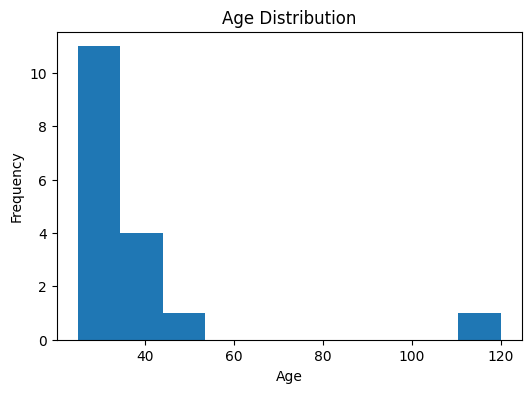

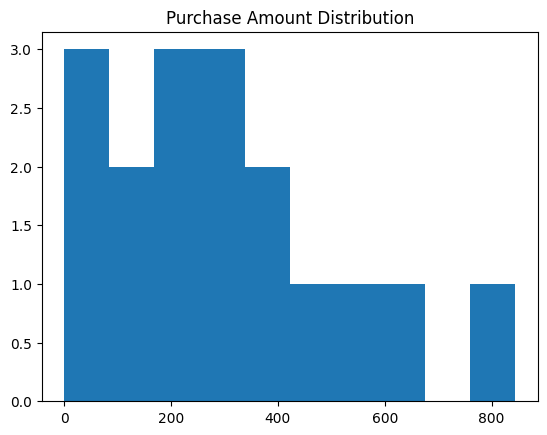

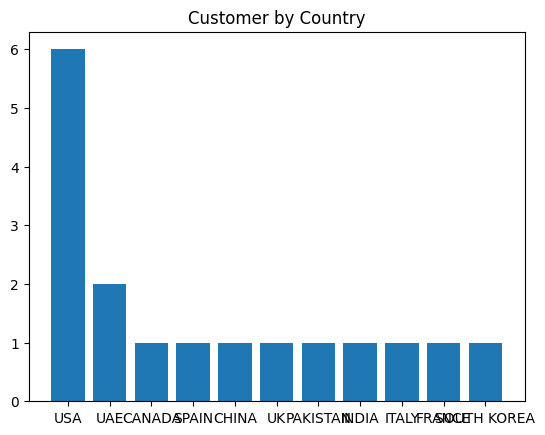

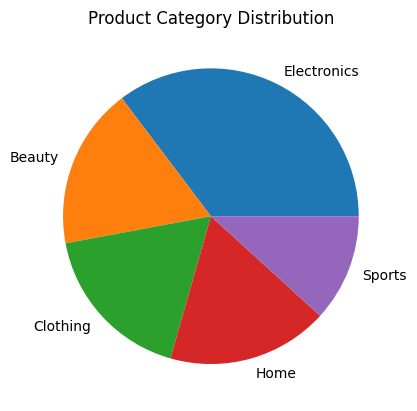

In [1764]:

### Challenge 2: Create Visualizations

# Create visualizations to show:
# 1. Age distribution (histogram)
# plt.hist(df_clean['age'])
# plt.title("Age Distribution")
# plt.show()
plt.figure(figsize=(6,4))
plt.hist(df_clean['age'])
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")
plt.show()


# 2. Purchase amount distribution (histogram)
plt.hist(df_clean['purchase_amount'])
plt.title("Purchase Amount Distribution")
plt.show()


#
# 3. Customer distribution by country (bar chart)
c=df_clean['country'].value_counts()
plt.bar(c.index,c.values)
plt.title("Customer by Country")
plt.show()

# 4. Product category distribution (pie chart)
p=df_clean['product_category'].value_counts()
plt.pie(p,labels=p.index)
plt.title("Product Category Distribution")
plt.show()

In [1765]:
### Challenge 3: Advanced Outlier Detection

# Implement Z-score method for outlier detection and compare results with IQR method.

# **Formula:** Z-score = (value - mean) / standard_deviation

# **Threshold:** |Z-score| > 3
'''
##
Standard Normal Distribution (Z-distribution) with z-score = 1.5
it is also  standard score, measures how many standard
 deviations a data point is from the mean of a dataset
The z-score formula is given by:
z = (x - μ) / σ
where:
x is the raw score,
μ is the mean of the data set, and
σ is the standard deviation
'''
print("we should take df2 not df because df has cleaned data with removed outliers")
df2=df.copy()

mean=df2['purchase_amount'].mean()
std=df2['purchase_amount'].std()

df2['z_score']=((df2['purchase_amount']-mean)/std)

print(df2[['purchase_amount','z_score']])

z_outliers=df2[np.abs(df2['z_score'])>3]

print("Z score based on outliers:")
print(z_outliers['purchase_amount'])
print("Z-score outlier count:",len(z_outliers))

q1=df2['purchase_amount'].quantile(0.25)
q3=df2['purchase_amount'].quantile(0.75)
iqr=q3-q1
lower=q1-1.5*iqr
upper=q3+1.5*iqr

iqr_outliers=df2[(df2['purchase_amount']<lower)|(df2['purchase_amount']>upper)]

if len(z_outliers)==0 and len(iqr_outliers)>0:
    print("IQR detected outliers but Z-score did not")

print("IQR outlier count:",len(iqr_outliers))
print("IQR outlier values")
print(iqr_outliers['purchase_amount'])

we should take df2 not df because df has cleaned data with removed outliers
    purchase_amount   z_score
0            250.75 -0.222631
1            340.00 -0.182912
2            120.50 -0.280596
3              0.00 -0.334222
4            -50.00 -0.356474
5            560.99 -0.084565
6            300.00 -0.200714
7             75.25 -0.300734
8           9999.00  4.115625
9               NaN       NaN
10           450.00 -0.133959
11           220.75 -0.235982
12           180.00 -0.254117
13           310.40 -0.196085
14            95.99 -0.291504
15           410.00 -0.151760
16           275.60 -0.211572
17           600.00 -0.067205
18           -20.00 -0.343123
19           150.00 -0.267468
Z score based on outliers:
8    9999.0
Name: purchase_amount, dtype: float64
Z-score outlier count: 1
IQR outlier count: 1
IQR outlier values
8    9999.0
Name: purchase_amount, dtype: float64


In [1766]:
print("checking datatypes and missing values")
print(df_clean.info())
# df_clean.describe()
# df_clean.describe(include='all')


checking datatypes and missing values
<class 'pandas.core.frame.DataFrame'>
Index: 17 entries, 0 to 17
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   customer_id        17 non-null     int64         
 1   customer_name      17 non-null     object        
 2   email              17 non-null     object        
 3   phone              17 non-null     object        
 4   registration_date  17 non-null     datetime64[ns]
 5   country            17 non-null     object        
 6   age                17 non-null     int64         
 7   purchase_amount    17 non-null     float64       
 8   product_category   17 non-null     category      
 9   payment_method     17 non-null     category      
 10  email_valid        17 non-null     bool          
dtypes: bool(1), category(2), datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 1.7+ KB
None


In [1767]:
print(df_clean.describe())
print(df_clean)


       customer_id              registration_date         age  purchase_amount
count    17.000000                             17   17.000000        17.000000
mean      9.470588  2023-05-20 09:52:56.470588160   38.588235       299.087059
min       1.000000            2022-12-30 00:00:00   25.000000         0.000000
25%       5.000000            2023-01-10 00:00:00   30.000000       120.500000
50%       9.000000            2023-05-25 00:00:00   33.000000       275.600000
75%      14.000000            2023-09-01 00:00:00   39.000000       410.000000
max      18.000000            2023-11-15 00:00:00  120.000000       844.250000
std       5.501337                            NaN   21.636366       222.369654
    customer_id customer_name                   email     phone  \
0             1      John Doe      john.doe@email.com  456-7890   
1             2    Jane Smith    jane.smith@email.com  456-7890   
2             3   Alice Brown         alice@email.com  456-7890   
3             4      

In [1768]:
print("Data Cleaning Impact:")
print(f"Missing values reduced from {df.isna().sum().sum()} to {df_clean.isna().sum().sum()}")
print(f"Duplicates removed: {df.duplicated().sum()}")
print(f"Outliers capped using IQR method")


Data Cleaning Impact:
Missing values reduced from 13 to 0
Duplicates removed: 0
Outliers capped using IQR method


In [1769]:
# ## Submission Checklist

# Before submitting your lab, ensure you have:

# - Completed all tasks in Parts 1-9
# - Written clean, well-commented code
# - Verified that all assertions pass
# - Created the cleaned dataset CSV file
# - Documented your cleaning strategy and decisions
# - Answered all questions throughout the lab
# - (Optional) Completed challenge tasks

# ## Evaluation Criteria

# Your lab will be evaluated on:

# 1. **Correctness (40%)**: All cleaning operations performed correctly
# 2. **Completeness (30%)**: All tasks completed
# 3. **Code Quality (15%)**: Clean, readable, well-commented code
# 4. **Analysis (15%)**: Quality of data quality assessment and decision-making

# ---

# ## Tips
# 1. **Work Incrementally**: Complete one section at a time and verify results before moving on
# 2. **Use `.copy()`**: Always work on a copy of your data to preserve the original
# 3. **Print Often**: Display results after each operation to verify correctness
# 4. **Read Documentation**: Refer to Pandas documentation when unsure about methods
# 5. **Test Assumptions**: Use assertions to validate your assumptions about the data
# 6. **Document Decisions**: Comment your code to explain why you chose specific cleaning strategies
# ---
# ## Additional Resources
# - Pandas Documentation: https://pandas.pydata.org/docs/
# - Data Cleaning Guide: https://pandas.pydata.org/docs/user_guide/missing_data.html
# - Regular Expressions: https://docs.python.org/3/library/re.html